# 04 · Modelling

**Three models** and **two baselines**, with cross-validation, hyperparameter
tuning and MLflow tracking.

The ladder is deliberate: logistic regression, then a tree, then a forest. Each one
exists because the previous one has a specific limitation the EDA already exposed.
Nothing is tried "to see what happens".

The metric that decides is **average precision**. Not accuracy, which the class
imbalance makes meaningless, and not ROC-AUC, which is too generous when the
majority class is this large.

In [1]:
import sys
sys.path.append("../src")

from config import bootstrap

ctx = bootstrap()
spark, w = ctx.spark, ctx.w

connected to Databricks
  branch   : sandbox
  catalog  : bank_churn_eng
  identity : resolved (19 chars, not printed)


In [2]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, precision_score
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,
                                     StratifiedKFold, cross_validate, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from config import UC_CATALOG, RANDOM_STATE

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = RANDOM_STATE
np.random.seed(SEED)

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

CHURN, GREY = "#a8471f", "#78736a"

df = spark.table(f"{UC_CATALOG}.silver.customers_clean").toPandas()
df["exited"] = df["exited"].astype(bool)
print(f"{len(df):,} rows | churn rate {df['exited'].mean():.2%}")

10,000 rows | churn rate 20.37%


## 1 · Feature selection

Exclusions are justified by what the EDA established, not by habit.

| Column | Decision | Why |
|---|---|---|
| `customer_id` | Excluded | Identifier. Used to return predictions to the CRM, never as a predictor |
| `credit_score_band` | Excluded | Redundant with `credit_score`, which the tree can cut on its own |
| `age_group` | Linear models only | Lets them bend where the relationship is non-monotonic. The tree finds its own cuts |
| `products_group` | Linear models only | Same reasoning |
| `age`, `num_of_products` | Trees only | Raw, so the tree can place its own thresholds |

The table below is generated from the code rather than written by hand. A feature
selection that can only be reconstructed by reading three cells is not documented.

In [3]:
TARGET = "exited"

# Columns by model family
CAT_LINEAR = ["geography", "gender", "age_group", "products_group"]
NUM_LINEAR = ["credit_score", "balance", "tenure", "estimated_salary"]
BINARY     = ["balance_zero", "is_active_member", "has_cr_card"]

CAT_TREE   = ["geography", "gender"]
NUM_TREE   = ["credit_score", "balance", "tenure", "estimated_salary",
              "age", "num_of_products"]

SENSITIVE  = ["geography", "gender"]

FEATURES = sorted(set(CAT_LINEAR + NUM_LINEAR + BINARY + CAT_TREE + NUM_TREE))

X = df[FEATURES].copy()
for c in BINARY:
    X[c] = X[c].astype(int)
y = df[TARGET].copy()

destination = pd.DataFrame([{
    "variable": v,
    "logistic": ("one-hot" if v in CAT_LINEAR else
                 "scaled"  if v in NUM_LINEAR else
                 "as-is"   if v in BINARY else "-"),
    "tree":     ("one-hot" if v in CAT_TREE else
                 "raw"     if v in NUM_TREE else
                 "as-is"   if v in BINARY else "-"),
} for v in FEATURES]).set_index("variable")

print(destination.to_string())
print(f"\n{len(FEATURES)} input columns")

                 logistic     tree
variable                          
age                     -      raw
age_group         one-hot        -
balance            scaled      raw
balance_zero        as-is    as-is
credit_score       scaled      raw
estimated_salary   scaled      raw
gender            one-hot  one-hot
geography         one-hot  one-hot
has_cr_card         as-is    as-is
is_active_member    as-is    as-is
num_of_products         -      raw
products_group    one-hot        -
tenure             scaled      raw

13 input columns


## 2 · Train / test split

Stratified on the target, with a fixed seed. **From here on the test set does not
exist** for this notebook: it is written to a Delta table and the variables are
deleted from the namespace.

That `del` is not theatre. In a notebook, where cells run out of order and get
re-executed, the easiest way to leak is to evaluate on test "just to check" and
then keep tuning. Removing the object from scope makes the mistake impossible
rather than merely discouraged.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print(f"train : {len(X_train):,} rows | rate {y_train.mean():.2%}")
print(f"test  : {len(X_test):,} rows | rate {y_test.mean():.2%}")
print(f"\nstratification holds: {abs(y_train.mean() - y_test.mean()) < 0.005}")

# The test set is persisted for notebook 05 and not touched again.
test_ref = (X_test.assign(exited=y_test)
                  .assign(customer_id=df.loc[X_test.index, "customer_id"].values))
(spark.createDataFrame(test_ref).write.format("delta").mode("overwrite")
      .option("overwriteSchema", "true")
      .saveAsTable(f"{UC_CATALOG}.silver.test_holdout"))
print(f"\ntest held out in {UC_CATALOG}.silver.test_holdout")

del X_test, y_test          # out of scope: it cannot be looked at by accident

train : 8,000 rows | rate 20.38%
test  : 2,000 rows | rate 20.35%

stratification holds: True

test held out in bank_churn_eng.silver.test_holdout


## 3 · One preprocessor per family

Not one preprocessor, **one per model family**, and the difference is not
cosmetic.

Scaling matters to logistic regression because it compares coefficients across
variables; a tree only compares values within a single column, so scaling changes
nothing for it. Binned age helps a linear model bend; a tree would rather have the
raw number and choose its own cut points.

Everything sits inside the `Pipeline`, which means it is fitted **inside each
cross-validation fold**. A scaler fitted outside would have seen the validation
rows of every fold, and every number reported afterwards would be quietly
optimistic.

In [5]:
def make_prep(cat_cols, num_cols, bin_cols, scale):
    """ColumnTransformer parameterised by model family."""
    num_tf = StandardScaler() if scale else "passthrough"
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
            ("num", num_tf, num_cols),
            ("bin", "passthrough", bin_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


prep_linear = make_prep(CAT_LINEAR, NUM_LINEAR, BINARY, scale=True)
prep_tree   = make_prep(CAT_TREE,   NUM_TREE,   BINARY, scale=False)

# Versions without the sensitive variables, for the cost measurement in section 10
prep_linear_ns = make_prep([c for c in CAT_LINEAR if c not in SENSITIVE], NUM_LINEAR, BINARY, True)
prep_tree_ns   = make_prep([c for c in CAT_TREE   if c not in SENSITIVE], NUM_TREE,   BINARY, False)


def breakdown(prep, cat_cols, num_cols, bin_cols, label):
    """Where the output columns come from. Fitted on a copy, never reused."""
    out = clone(prep).fit(X_train).get_feature_names_out()
    print(f"{label}: {len(cat_cols)} categorical + {len(num_cols)} numeric + "
          f"{len(bin_cols)} binary  ->  {len(out)} columns")
    print(f"  {', '.join(out)}\n")


breakdown(prep_linear, CAT_LINEAR, NUM_LINEAR, BINARY, "linear")
breakdown(prep_tree,   CAT_TREE,   NUM_TREE,   BINARY, "tree  ")
print("One-hot expands each category into k-1 columns (drop='first' avoids the")
print("dummy trap). That is where the difference in totals comes from.")

linear: 4 categorical + 4 numeric + 3 binary  ->  16 columns
  geography_Germany, geography_Spain, gender_Male, age_group_30-39, age_group_40-49, age_group_50-59, age_group_60+, products_group_2, products_group_3+, credit_score, balance, tenure, estimated_salary, balance_zero, is_active_member, has_cr_card

tree  : 2 categorical + 6 numeric + 3 binary  ->  12 columns
  geography_Germany, geography_Spain, gender_Male, credit_score, balance, tenure, estimated_salary, age, num_of_products, balance_zero, is_active_member, has_cr_card

One-hot expands each category into k-1 columns (drop='first' avoids the
dummy trap). That is where the difference in totals comes from.


## 4 · The business baseline as an estimator

For the comparison to be legitimate, the practical rule has to go through the same
cross-validation as everything else. So it is written as a scikit-learn estimator
rather than computed on the side.

This is where the sklearn contract stops being trivia. **Two details below each
caused a real failure**, and both are worth knowing:

1. **The mixin comes first in the inheritance list.** With
   `(BaseEstimator, ClassifierMixin)` sklearn resolves the estimator type through
   the MRO and classifies the object as a **regressor**. `average_precision` then
   returns `NaN` with no clear error.

2. **`__init__` only assigns.** Any conversion — even `list(cols)` — has to happen
   in `fit`. `clone()` rebuilds the estimator from `get_params()` and requires the
   stored parameters to be identical to the ones received.

In [6]:
class BusinessRule(ClassifierMixin, BaseEstimator):
    """Segment churn rate over age band x activity.

    What an analyst would produce in an afternoon with no model at all. It is
    fitted on training data like any other estimator, so it goes through the same
    cross-validation and the comparison is honest.
    """

    def __init__(self, cols=("age_group", "is_active_member")):
        # Only assignment. No list(), no validation, no derived attributes.
        self.cols = cols

    def fit(self, X, y):
        cols = list(self.cols)                    # the conversion belongs here
        self.classes_ = np.array([False, True])
        frame = X[cols].copy()
        frame["_y"] = np.asarray(y).astype(int)
        self.rates_ = frame.groupby(cols)["_y"].mean()
        self.prior_ = float(frame["_y"].mean())
        return self

    def predict_proba(self, X):
        idx = pd.MultiIndex.from_frame(X[list(self.cols)])
        p = pd.Series(self.rates_.reindex(idx).values, index=X.index).fillna(self.prior_)
        return np.column_stack([1 - p.values, p.values])

    def predict(self, X):
        return self.predict_proba(X)[:, 1] >= 0.5


print("contract check:")
probe = BusinessRule().fit(X_train, y_train)
from sklearn.base import is_classifier
print(f"  is_classifier      : {is_classifier(probe)}")
print(f"  clone() round-trips: {clone(probe).get_params() == probe.get_params()}")
print(f"  segments learned   : {len(probe.rates_)}")

contract check:
  is_classifier      : True
  clone() round-trips: True
  segments learned   : 10


## 5 · Candidate models

| Model | Why it is here |
|---|---|
| `baseline_dummy` | Always predicts the majority class. Proves accuracy is useless |
| `baseline_business` | The two-variable rule. **The rival that actually matters** |
| `logistic` | Interpretable reference. If it wins, nothing more is needed |
| `tree` | Captures interactions without being told. The EDA found one |
| `random_forest` | Fixes the tree's instability by averaging |

### Why KNN and SVM are not here

**KNN** classifies by proximity, and "proximity" has no meaning across these
columns. It would mix euros of balance, years of age and a country into one
distance. It can be normalised, but the resulting number does not correspond to
anything real.

**SVM** has a more concrete problem: it does not produce probabilities natively.
It returns a side of a boundary. This system does not need a yes or no, it needs to
**rank** the portfolio to allocate 800 calls. Without probability there is no
ranking.

Neither was rejected on performance. They were rejected because they do not fit the
shape of the decision — and testing a model you could not use even if it won is
time spent on nothing.

In [7]:
def pipe(prep, clf):
    return Pipeline([("prep", clone(prep)), ("clf", clf)])


models = {
    "baseline_dummy":   pipe(prep_tree, DummyClassifier(strategy="most_frequent")),
    "baseline_business": BusinessRule(),        # no preprocessor: it reads raw columns
    "logistic": pipe(prep_linear, LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=SEED)),
    "tree": pipe(prep_tree, DecisionTreeClassifier(
        class_weight="balanced", max_depth=5, random_state=SEED)),
    "random_forest": pipe(prep_tree, RandomForestClassifier(
        class_weight="balanced_subsample", n_estimators=300,
        random_state=SEED, n_jobs=-1)),
}

for k in models:
    print(" ", k)

  baseline_dummy
  baseline_business
  logistic
  tree
  random_forest


## 6 · Cross-validation

Five stratified folds. Stratified means each fold keeps the churn proportion of the
whole set — without it one fold might get 15% and another 25%, and the five scores
would not be comparable.

`zero_division=0` on precision exists for a specific reason: the dummy never
predicts class 1, so its precision is 0/0. Without it sklearn raises an
`UndefinedMetricWarning` per fold — five red warnings above the table — that looks
like a bug and is not. It is exactly the result being demonstrated.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

METRICS = {
    "average_precision": "average_precision",
    "roc_auc":           "roc_auc",
    "recall":            "recall",
    "precision":         make_scorer(precision_score, zero_division=0),
    "f1":                "f1",
    "accuracy":          "accuracy",
}

rows = []
for name, model in models.items():
    r = cross_validate(model, X_train, y_train, cv=cv, scoring=METRICS, n_jobs=-1)
    row = {"model": name}
    for m in METRICS:
        row[m] = r[f"test_{m}"].mean()
        row[f"{m}_std"] = r[f"test_{m}"].std()
    rows.append(row)

cv_res = pd.DataFrame(rows).set_index("model").sort_values("average_precision", ascending=False)
print(cv_res[list(METRICS)].round(4).to_string())

print("\nRead the accuracy column: baseline_dummy scores near 0.80 while its")
print("recall is 0. That single line is the whole argument against accuracy.")

                   average_precision  roc_auc  recall  precision      f1  accuracy
model                                                                             
random_forest                 0.6702   0.8556  0.4442     0.7674  0.5624    0.8594
logistic                      0.6452   0.8416  0.7448     0.4664  0.5735    0.7744
tree                          0.6073   0.8275  0.7515     0.4495  0.5623    0.7618
baseline_business             0.4677   0.7526  0.2006     0.8165  0.3216    0.8280
baseline_dummy                0.2037   0.5000  0.0000     0.0000  0.0000    0.7962

Read the accuracy column: baseline_dummy scores near 0.80 while its
recall is 0. That single line is the whole argument against accuracy.


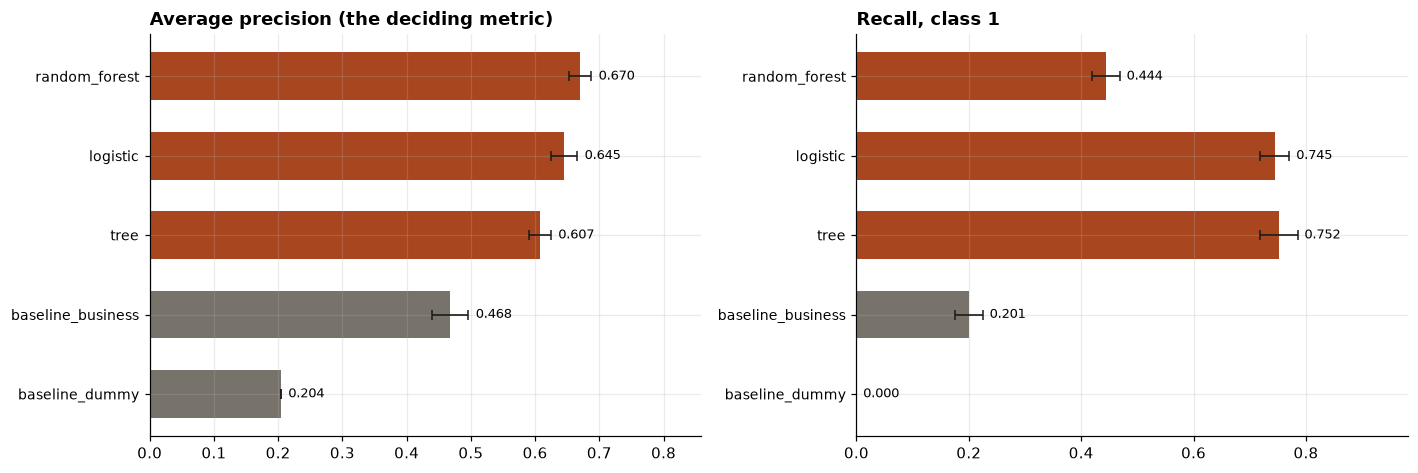

Grey bars are the baselines. The one to beat is baseline_business.


In [9]:
# Figure 1 - comparison with error bars.
# The bars matter: a 0.003 gap between two models whose folds vary by 0.017 is
# not a gap, it is noise.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
order = cv_res.index.tolist()

for ax, met, title in zip(axes, ["average_precision", "recall"],
                          ["Average precision (the deciding metric)", "Recall, class 1"]):
    v, e = cv_res.loc[order, met], cv_res.loc[order, f"{met}_std"]
    colours = [GREY if "baseline" in m else CHURN for m in order]
    ax.barh(np.arange(len(order)), v, xerr=e, color=colours, height=0.6,
            error_kw=dict(ecolor="#1c1a17", lw=1.1, capsize=3))
    ax.set_yticks(np.arange(len(order))); ax.set_yticklabels(order, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11.5, fontweight="bold", loc="left")
    for i, (val, err) in enumerate(zip(v, e)):
        ax.text(val + err + 0.012, i, f"{val:.3f}", va="center", fontsize=8.5)
    ax.set_xlim(0, min(1.0, (v + e).max() * 1.25))

plt.tight_layout(); plt.show()
print("Grey bars are the baselines. The one to beat is baseline_business.")

## 7 · Feature importance, and its two traps

**Permutation importance**, not the forest's built-in impurity importance. The
built-in one favours variables with many distinct values regardless of whether they
carry signal; permutation measures what the model actually uses, by shuffling a
column and seeing how much the score drops.

It has two traps, and both are easy to fall into.

In [10]:
best_name = next(m for m in cv_res.index if "baseline" not in m)
print("model under inspection:", best_name, "\n")

# TRAP 2 - measuring on training data.
# On rows the model has seen, importance reflects how much it MEMORISED a column,
# not how much that column helps it predict. An internal split solves it, and the
# real test set stays untouched.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=SEED)
model_imp = clone(models[best_name]).fit(X_fit, y_fit)
print(f"fit on {len(X_fit):,} rows | importance measured on {len(X_val):,} unseen rows\n")

# TRAP 1 - permuting columns the model never sees.
# The forest gets raw age and drops age_group. Permuting a column the pipeline
# discards gives importance exactly zero, and those phantom zeros push genuinely
# useful variables down the table.
prep_fitted = model_imp.named_steps["prep"]
# transformers_ also carries the ('remainder', 'drop', [...]) entry. Including
# it would list precisely the columns the pipeline THROWS AWAY, which is trap 1
# happening for real: they come out with importance exactly zero and push the
# variables that matter down the table.
used = sorted({c for name, trans, cols in prep_fitted.transformers_
               if name != "remainder" and trans != "drop"
               for c in (cols if isinstance(cols, list) else [])})
ignored = [c for c in X_train.columns if c not in used]

print(f"used by the pipeline ({len(used)}): {', '.join(used)}")
print(f"ignored ({len(ignored)}): {', '.join(ignored) or 'none'}")

model under inspection: random_forest 

fit on 6,000 rows | importance measured on 2,000 unseen rows

used by the pipeline (11): age, balance, balance_zero, credit_score, estimated_salary, gender, geography, has_cr_card, is_active_member, num_of_products, tenure
ignored (2): age_group, products_group


                  importance     std  distinguishable
variable                                             
age                   0.2567  0.0113             True
num_of_products       0.2375  0.0101             True
is_active_member      0.0923  0.0155             True
geography             0.0692  0.0076             True
balance               0.0622  0.0077             True
balance_zero          0.0145  0.0040             True
estimated_salary      0.0048  0.0062            False
tenure                0.0035  0.0035            False
has_cr_card           0.0021  0.0037            False
gender                0.0012  0.0047            False
credit_score         -0.0014  0.0041            False


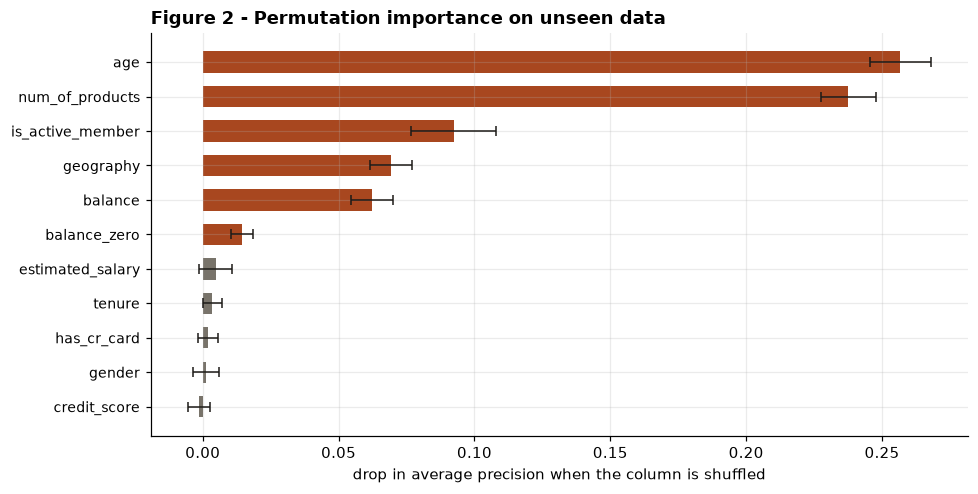

Grey bars: effect not distinguishable from zero.


In [11]:
r = permutation_importance(model_imp, X_val[used], y_val, n_repeats=15,
                           random_state=SEED, scoring="average_precision", n_jobs=-1)

imp = (pd.DataFrame({"variable": used,
                     "importance": r.importances_mean,
                     "std": r.importances_std})
         .set_index("variable")
         .sort_values("importance", ascending=False))

# A variable whose importance is smaller than its own error is indistinguishable
# from zero. Ordering within that group is reading noise.
imp["distinguishable"] = imp["importance"] > imp["std"]
print(imp.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 4.6))
colours = [CHURN if d else GREY for d in imp["distinguishable"]]
ax.barh(np.arange(len(imp)), imp["importance"], xerr=imp["std"],
        color=colours, height=0.62, error_kw=dict(ecolor="#1c1a17", lw=1, capsize=3))
ax.set_yticks(np.arange(len(imp))); ax.set_yticklabels(imp.index, fontsize=9)
ax.invert_yaxis()
ax.set_title("Figure 2 - Permutation importance on unseen data", fontsize=11.5,
             fontweight="bold", loc="left")
ax.set_xlabel("drop in average precision when the column is shuffled")
plt.tight_layout(); plt.show()
print("Grey bars: effect not distinguishable from zero.")

### Auditing predictions P2 and P3

Both were registered in notebook 00, before any model existed.

In [12]:
top3     = list(imp.index[:3])
expected = {"age", "num_of_products", "is_active_member"}
p2 = expected == set(top3)

tail      = list(imp.index[-4:])
exp_tail  = {"credit_score", "tenure", "estimated_salary", "has_cr_card"}
hits      = len(exp_tail & set(tail))
p3        = exp_tail == set(tail)

print("P2 - the three most important will be age, num_of_products, is_active_member")
print(f"     observed: {top3}")
print(f"     -> {'CONFIRMED' if p2 else 'REFUTED'}\n")

print("P3 - credit_score, tenure, estimated_salary and has_cr_card will be last")
print(f"     observed: {tail}")
print(f"     hits    : {hits} of 4")
print(f"     -> {'CONFIRMED' if p3 else f'PARTIAL ({hits}/4)' if hits >= 3 else 'REFUTED'}")

noise = imp[~imp["distinguishable"]]
print(f"\n{len(noise)} variables sit inside the noise floor: {list(noise.index)}")
print("Among variables whose importance is smaller than their own error, the")
print("ordering is not interpretable. P3 holds in substance -- those variables")
print("carry no signal -- and not to the letter, because the exact position was")
print("never measurable at this precision. It is reported as partial.")

P2 - the three most important will be age, num_of_products, is_active_member
     observed: ['age', 'num_of_products', 'is_active_member']
     -> CONFIRMED

P3 - credit_score, tenure, estimated_salary and has_cr_card will be last
     observed: ['tenure', 'has_cr_card', 'gender', 'credit_score']
     hits    : 3 of 4
     -> PARTIAL (3/4)

5 variables sit inside the noise floor: ['estimated_salary', 'tenure', 'has_cr_card', 'gender', 'credit_score']
Among variables whose importance is smaller than their own error, the
ordering is not interpretable. P3 holds in substance -- those variables
carry no signal -- and not to the letter, because the exact position was
never measurable at this precision. It is reported as partial.


## 8 · Hyperparameter tuning

Grids kept deliberately small. A search over five thousand combinations on ten
thousand rows finds the configuration that best fits the noise of these particular
folds, and reports it as an improvement.

`refit="average_precision"` is what makes the search optimise the metric that
matches the problem rather than the default.

In [13]:
grids = {
    "logistic": (GridSearchCV, {
        "clf__C": [0.01, 0.1, 1.0, 10.0],
        "clf__penalty": ["l2"], "clf__solver": ["lbfgs"],
    }),
    "tree": (GridSearchCV, {
        "clf__max_depth": [3, 4, 5, 6, 8],
        "clf__min_samples_leaf": [10, 30, 60],
        "clf__criterion": ["gini", "entropy"],
    }),
    "random_forest": (RandomizedSearchCV, {
        "clf__n_estimators": [200, 400, 600],
        "clf__max_depth": [6, 10, 14, None],
        "clf__min_samples_leaf": [1, 5, 15, 30],
        "clf__max_features": ["sqrt", 0.4, 0.7],
    }),
}

candidates = [m for m in cv_res.index if "baseline" not in m][:3]
tuned, tuning_rows = {}, []

for name in candidates:
    Search, grid = grids[name]
    kw = dict(estimator=clone(models[name]), cv=cv, scoring=METRICS,
              refit="average_precision", n_jobs=-1)
    search = (Search(param_distributions=grid, n_iter=20, random_state=SEED, **kw)
              if Search is RandomizedSearchCV else Search(param_grid=grid, **kw))
    search.fit(X_train, y_train)
    tuned[name] = search
    i = search.best_index_
    tuning_rows.append({
        "model": name,
        "AP_base":  cv_res.loc[name, "average_precision"],
        "AP_tuned": search.cv_results_["mean_test_average_precision"][i],
        "AP_std":   search.cv_results_["std_test_average_precision"][i],
        "recall":   search.cv_results_["mean_test_recall"][i],
        "best_params": {k.replace("clf__", ""): v for k, v in search.best_params_.items()},
    })

tuning = pd.DataFrame(tuning_rows).set_index("model")
tuning["gain"] = (tuning["AP_tuned"] - tuning["AP_base"]).round(4)
print(tuning.round(4).to_string())
print("\nCompare each gain against its own AP_std before calling it an improvement.")

               AP_base  AP_tuned  AP_std  recall                                                                         best_params    gain
model                                                                                                                                       
random_forest   0.6702    0.6848  0.0217  0.6564  {'n_estimators': 400, 'min_samples_leaf': 5, 'max_features': 0.7, 'max_depth': 10}  0.0146
logistic        0.6452    0.6454  0.0197  0.7442                                     {'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs'}  0.0002
tree            0.6073    0.6389  0.0266  0.7276                    {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 30}  0.0315

Compare each gain against its own AP_std before calling it an improvement.


---

## 9 · The two models that can be read

The forest wins, and the price it pays is that **it cannot be shown**. Three hundred
trees averaged do not draw on a slide.

So the two runners-up get displayed, because each answers a question the forest
cannot. The tree shows *where* the decision splits. The logistic regression turns
its coefficients into a number a regulator can read.

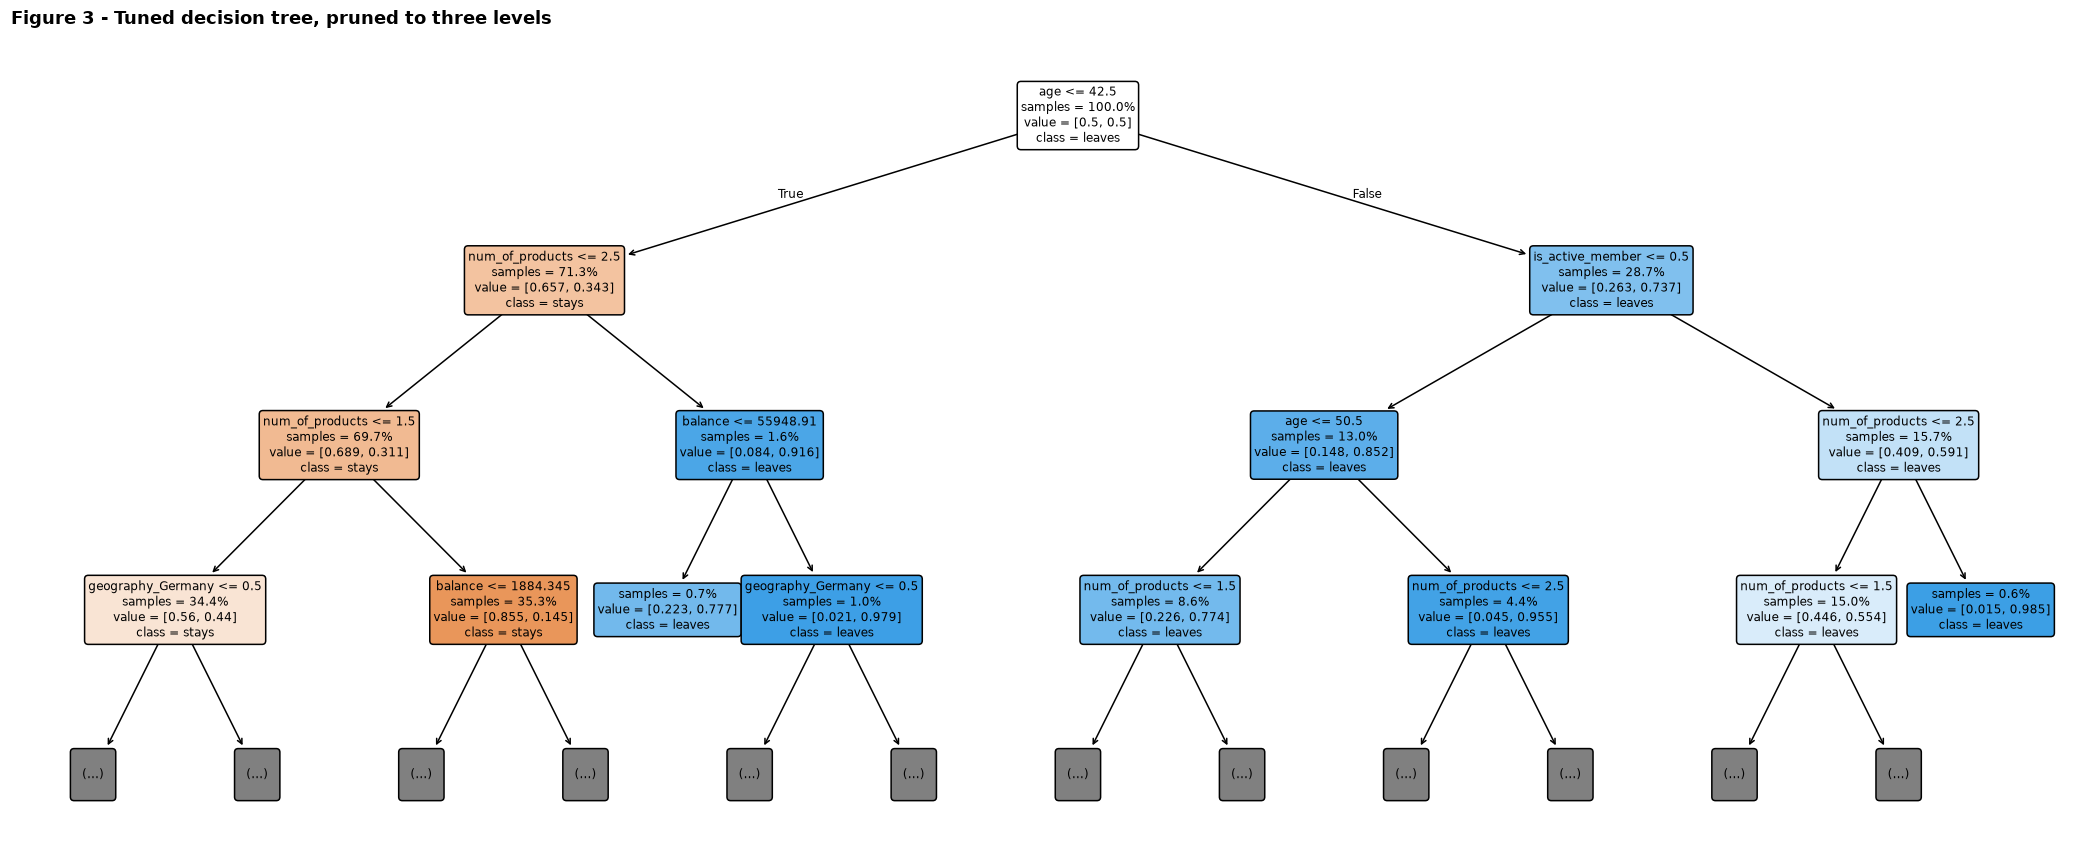

actual depth : 8
leaves       : 98

Look at the second level: it splits on age, then on activity inside the
older branch. That is the interaction the EDA found -- discovered here by
the algorithm alone, which is confirmation rather than coincidence.


In [14]:
from sklearn.tree import plot_tree

# The tuned tree is deeper than three levels. Drawing it whole is unreadable,
# so it is pruned to what fits on a screen.
tree_pipe = tuned["tree"].best_estimator_
tree_clf  = tree_pipe.named_steps["clf"]
names     = list(tree_pipe.named_steps["prep"].get_feature_names_out())

fig, ax = plt.subplots(figsize=(19, 8))
plot_tree(tree_clf, max_depth=3, feature_names=names,
          class_names=["stays", "leaves"], filled=True, rounded=True,
          proportion=True, impurity=False, fontsize=8, ax=ax)
ax.set_title("Figure 3 - Tuned decision tree, pruned to three levels",
             fontsize=12, fontweight="bold", loc="left")
plt.tight_layout(); plt.show()

print(f"actual depth : {tree_clf.get_depth()}")
print(f"leaves       : {tree_clf.get_n_leaves()}")
print()
print("Look at the second level: it splits on age, then on activity inside the")
print("older branch. That is the interaction the EDA found -- discovered here by")
print("the algorithm alone, which is confirmation rather than coincidence.")

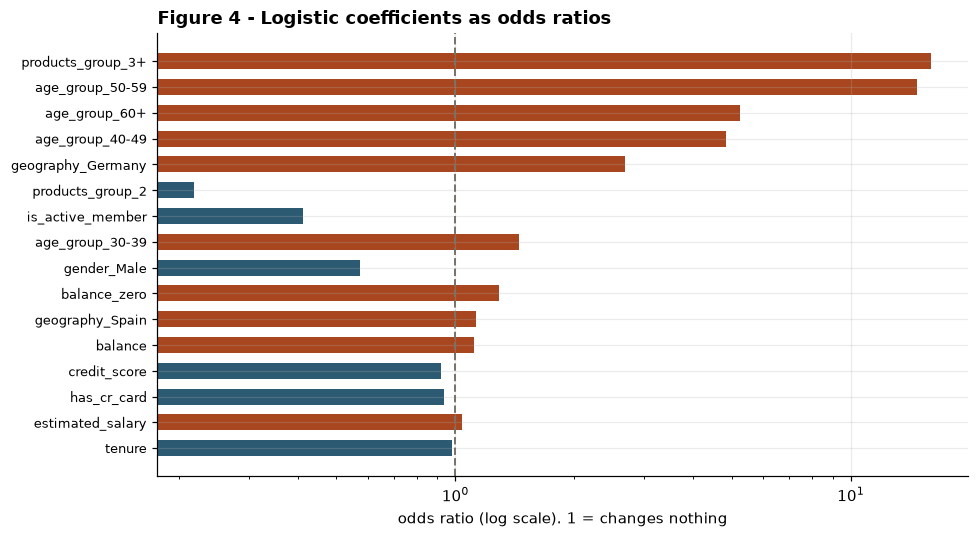

         variable  coefficient  odds_ratio      effect
products_group_3+       2.7709     15.9737 raises risk
  age_group_50-59       2.6898     14.7294 raises risk
    age_group_60+       1.6593      5.2558 raises risk
  age_group_40-49       1.5781      4.8460 raises risk
geography_Germany       0.9867      2.6823 raises risk
 products_group_2      -1.5196      0.2188   lowers it
 is_active_member      -0.8872      0.4118   lowers it
  age_group_30-39       0.3697      1.4473 raises risk
      gender_Male      -0.5523      0.5757   lowers it
     balance_zero       0.2523      1.2870 raises risk
  geography_Spain       0.1204      1.1279 raises risk
          balance       0.1081      1.1142 raises risk
     credit_score      -0.0847      0.9188   lowers it
      has_cr_card      -0.0682      0.9341   lowers it
 estimated_salary       0.0363      1.0370 raises risk
           tenure      -0.0205      0.9797   lowers it

Careful with the wording: an odds ratio is NOT a relative risk. 

In [15]:
# The logistic regression does not win, but it is the only one producing a number
# a regulator can read. A coefficient lives in log-odds and means nothing to
# anyone; exponentiating it turns it into a MULTIPLIER of the odds.
log_pipe = tuned["logistic"].best_estimator_
log_clf  = log_pipe.named_steps["clf"]
log_names = list(log_pipe.named_steps["prep"].get_feature_names_out())

coef = pd.DataFrame({
    "variable":    log_names,
    "coefficient": log_clf.coef_[0],
    "odds_ratio":  np.exp(log_clf.coef_[0]),
}).assign(effect=lambda d: np.where(d.odds_ratio > 1, "raises risk", "lowers it"))
coef = coef.reindex(coef.odds_ratio.sub(1).abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9, 5))
yy = np.arange(len(coef))
ax.barh(yy, coef["odds_ratio"], color=[CHURN if v > 1 else "#2c5a72" for v in coef["odds_ratio"]],
        height=0.62)
ax.axvline(1.0, color=GREY, ls="--", lw=1.3)
ax.set_yticks(yy); ax.set_yticklabels(coef["variable"], fontsize=8.5)
ax.invert_yaxis(); ax.set_xscale("log")
ax.set_xlabel("odds ratio (log scale). 1 = changes nothing")
ax.set_title("Figure 4 - Logistic coefficients as odds ratios", fontsize=11.5,
             fontweight="bold", loc="left")
plt.tight_layout(); plt.show()

print(coef.round(4).to_string(index=False))
print("\nCareful with the wording: an odds ratio is NOT a relative risk. It")
print("multiplies the ODDS, and at high probabilities the two diverge.")

## 10 · The cost of excluding the sensitive variables

Notebook 02 deliberately deferred this decision. Here it gets executed: instead of
deciding on principle, the same model is trained with and without `gender` and
`geography`, and the difference is measured.

Deciding without the number is a posture. Deciding against it is a decision.

In [16]:
best = tuning["AP_tuned"].idxmax()
print("selected model:", best)

prep_ns = prep_linear_ns if best == "logistic" else prep_tree_ns
clf_best = clone(tuned[best].best_estimator_.named_steps["clf"])
model_ns = Pipeline([("prep", clone(prep_ns)), ("clf", clf_best)])

r_with = cross_validate(clone(tuned[best].best_estimator_), X_train, y_train,
                        cv=cv, scoring=METRICS, n_jobs=-1)
r_without = cross_validate(model_ns, X_train, y_train, cv=cv, scoring=METRICS, n_jobs=-1)

comp = pd.DataFrame({
    "with_sensitive":    {m: r_with[f"test_{m}"].mean() for m in METRICS},
    "without_sensitive": {m: r_without[f"test_{m}"].mean() for m in METRICS},
})
comp["difference_pp"] = ((comp["with_sensitive"] - comp["without_sensitive"]) * 100).round(2)
print(comp.round(4).to_string())

cost_recall = comp.loc["recall", "difference_pp"]
n_customers = int(abs(cost_recall) / 100 * y_train.sum())
print(f"\n--- COST OF EXCLUDING gender AND geography ---")
print(f"  recall            : {cost_recall:+.2f} points")
print(f"  roughly           : {n_customers} customers per campaign")
print(f"  average precision : {comp.loc['average_precision', 'difference_pp']:+.2f} points")

selected model: random_forest
                   with_sensitive  without_sensitive  difference_pp
average_precision          0.6848             0.6552           2.96
roc_auc                    0.8593             0.8420           1.73
recall                     0.6564             0.6258           3.07
precision                  0.5721             0.5553           1.68
f1                         0.6110             0.5881           2.29
accuracy                   0.8301             0.8216           0.85

--- COST OF EXCLUDING gender AND geography ---
  recall            : +3.07 points
  roughly           : 50 customers per campaign
  average precision : +2.96 points


### Reading the number

Whatever it comes out at, the argument has the same shape: this is what the
information costs, and it is weighed against using a protected characteristic to
allocate a benefit.

There is a second consideration that the number alone does not capture. Both
variables predict well **precisely because they proxy for something unmeasured** —
the EDA showed that neither Germany nor gender is distinguishable on any observable
variable. A model that relies on a proxy it cannot explain is one that cannot be
defended when someone asks why a particular customer was ranked where they were.

## 11 · MLflow

Every model is logged with its parameters, its cross-validation metrics and the
fitted artefact. The registration function **never raises**: if the tracking server
is unavailable the notebook carries on and says so.

That matters because a training run that dies at the logging step, after the fit
has already happened, wastes the expensive part for the cheap reason.

In [17]:
MLFLOW_OK = True

# The experiment is already set by bootstrap(), so every notebook logs into the
# same place and none of them can disagree about the name.
print("experiment:", mlflow.get_experiment(mlflow.active_run().info.experiment_id).name
      if mlflow.active_run() else mlflow.get_experiment_by_name(
          f"/Users/{ctx.pg_user}/{MLFLOW_EXPERIMENT}").name)

try:
    mlflow.sklearn.autolog(disable=True)      # explicit logging is cleaner
except Exception:
    pass


def log_run(name, params=None, metrics=None, model=None):
    """Log a run. Never raises: on failure it warns and returns None."""
    global MLFLOW_OK
    if not MLFLOW_OK:
        return None
    try:
        with mlflow.start_run(run_name=name) as run:
            if params:
                mlflow.log_params(params)
            if metrics:
                for k, v in metrics.items():
                    mlflow.log_metric(k, float(v))
            if model is not None:
                mlflow.sklearn.log_model(model, name="model")
            return run.info.run_id
    except Exception as e:
        print(f"[warn] MLflow unavailable ({type(e).__name__}); logging disabled")
        MLFLOW_OK = False
        return None

If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc


In [18]:
for name, search in tuned.items():
    i = search.best_index_
    log_run(f"{name}_tuned",
            params={**{k.replace("clf__", ""): v for k, v in search.best_params_.items()},
                    "family": name, "n_train": len(X_train), "sensitive_vars": True},
            metrics={f"cv_{m}": search.cv_results_[f"mean_test_{m}"][i] for m in METRICS} |
                    {f"cv_{m}_std": search.cv_results_[f"std_test_{m}"][i] for m in METRICS},
            model=search.best_estimator_)

for name in ["baseline_dummy", "baseline_business"]:
    log_run(name, params={"family": "baseline"},
            metrics={f"cv_{m}": cv_res.loc[name, m] for m in METRICS})

log_run(f"{best}_no_sensitive",
        params={"family": best, "sensitive_vars": False},
        metrics={f"cv_{m}": r_without[f"test_{m}"].mean() for m in METRICS})

print("runs logged")

🔗 View Logged Model at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913/models/m-<run_id>


🏃 View run random_forest_tuned at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913/runs/<run_id>
🧪 View experiment at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913


🔗 View Logged Model at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913/models/m-<run_id>


🏃 View run logistic_tuned at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913/runs/<run_id>
🧪 View experiment at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913


🔗 View Logged Model at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913/models/m-<run_id>


🏃 View run tree_tuned at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913/runs/<run_id>
🧪 View experiment at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913
🏃 View run baseline_dummy at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913/runs/<run_id>
🧪 View experiment at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913
🏃 View run baseline_business at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913/runs/<run_id>
🧪 View experiment at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913
🏃 View run random_forest_no_sensitive at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913/runs/<run_id>
🧪 View experiment at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913
runs logged


In [19]:
# The final model is trained whether or not MLflow is available.
final_model = clone(tuned[best].best_estimator_).fit(X_train, y_train)
print("final model trained:", best)

RUN_ID = log_run("final_model",
                 params={**{k.replace("clf__", ""): v for k, v in tuned[best].best_params_.items()},
                         "family": best},
                 metrics={"cv_average_precision": tuning.loc[best, "AP_tuned"],
                          "cv_recall": tuning.loc[best, "recall"]},
                 model=final_model)

# Plan B: the parameters alone are enough to rebuild it. With a fixed seed,
# reconstructing from these produces an identical model. Notebook 05 uses the
# run_id if it exists and the parameters otherwise.
ref = pd.DataFrame([{
    "run_id":            RUN_ID or "",
    "mlflow_available":  bool(RUN_ID),
    "family":            best,
    "params":            json.dumps({k.replace("clf__", ""): v
                                     for k, v in tuned[best].best_params_.items()}),
    "cv_average_precision": float(tuning.loc[best, "AP_tuned"]),
}])

(spark.createDataFrame(ref).write.format("delta").mode("overwrite")
      .option("overwriteSchema", "true")
      .saveAsTable(f"{UC_CATALOG}.gold.model_reference"))
print("reference written to gold.model_reference")

final model trained: random_forest


🔗 View Logged Model at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913/models/m-<run_id>


🏃 View run final_model at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913/runs/<run_id>
🧪 View experiment at: https://dbc-04c9ea21-2a95.cloud.databricks.com/ml/experiments/733594851517913
reference written to gold.model_reference


## 12 · Auditing the remaining predictions

In [20]:
ap_rf  = tuning.loc["random_forest", "AP_tuned"] if "random_forest" in tuning.index else np.nan
ap_log = tuning.loc["logistic",      "AP_tuned"] if "logistic"      in tuning.index else np.nan

print("P1 - Random Forest will beat logistic regression")
print(f"     RF {ap_rf:.4f}  vs  logistic {ap_log:.4f}")
print(f"     -> {'CONFIRMED' if ap_rf > ap_log else 'REFUTED'}\n")

ap_business = cv_res.loc["baseline_business", "average_precision"]
ap_best     = tuning.loc[best, "AP_tuned"]

print("MAIN CRITERION - beat the business baseline")
print(f"     business rule {ap_business:.4f}  vs  {best} {ap_best:.4f}")
print(f"     -> {'MET' if ap_best > ap_business else 'NOT MET'}")
print(f"     margin: {(ap_best - ap_business):+.4f} AP")

if ap_best <= ap_business:
    print("\n  The model does not justify its cost against a two-variable rule.")
    print("  That is a legitimate result and it would be reported as such.")

P1 - Random Forest will beat logistic regression
     RF 0.6848  vs  logistic 0.6454
     -> CONFIRMED

MAIN CRITERION - beat the business baseline
     business rule 0.4677  vs  random_forest 0.6848
     -> MET
     margin: +0.2171 AP


---

## Summary

| | |
|---|---|
| Models evaluated | 3 + 2 baselines |
| Deciding metric | Average precision |
| Validation | 5-fold stratified, everything inside the `Pipeline` |
| Test set | Held out in `silver.test_holdout`, **untouched** |
| Predictions audited | P1, P2, P3 |
| Tracking | MLflow, with a parameter-based fallback |

P4 and P5 need the test set, so they are audited in notebook 05.

**Next:** `05_evaluation` — open the test set once, calibrate, set the threshold by
capacity, and report the two criteria that were not met.